In [1]:
# 1. Import essential libraries
import pandas as pd
import numpy as np

# 2. Load the dataset
file_path = '../data/raw/amazon_reviews.csv' # Make sure this matches your exact file name

try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully!")
    
    # 3. Display the first 5 rows to understand the data structure
    display(df.head())
    
    # 4. Display a quick summary of the data (rows, columns, data types, etc.)
    print("\nData Information:")
    print(df.info())
    
except FileNotFoundError:
    print("Error: Please check the file name and path.")

Data loaded successfully!


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  re

In [ ]:
# 1. Import necessary text processing libraries
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords list
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 2. Select only the relevant columns for Sentiment Analysis
df = df[['reviews.text', 'reviews.rating']]

# 3. Drop any rows that have missing values (NaN) to avoid errors
df = df.dropna()

# 4. Create a binary 'sentiment' column
# Ratings of 4 and 5 are Positive (1). Ratings of 1 and 2 are Negative (0).
# We will drop the neutral ratings (3) to make the model's job clearer.
df = df[df['reviews.rating'] != 3.0]

# Use np.where to assign 1 if rating > 3, else 0
df['sentiment'] = np.where(df['reviews.rating'] > 3.0, 1, 0)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# 5. Define the text cleaning function
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters, punctuation, and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove stopwords (e.g., 'the', 'is', 'in')
    text = " ".join([word for word in text.split() if word not in stop_words])
    
    return text

# 6. Apply the cleaning function to the review text
print("\nCleaning text data... Please wait.")
df['cleaned_text'] = df['reviews.text'].apply(clean_text)

print("Text cleaning complete!")

# 7. Display the final processed dataframe ready for the model
display(df[['cleaned_text', 'sentiment']].head())


Sentiment Distribution:
sentiment
1    977
0     76
Name: count, dtype: int64

Cleaning text data... Please wait.
Text cleaning complete!


[nltk_data] Downloading package stopwords to C:\Users\Alsayad
[nltk_data]     Electronics\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,cleaned_text,sentiment
0,initially trouble deciding paperwhite voyage r...,1
1,allow preface little history casual reader own...,1
2,enjoying far great reading original fire since...,1
3,bought one first paperwhites pleased constant ...,1
4,say upfront dont like coroporate hermetically ...,1


In [4]:
# 1. Import ML libraries from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib # For saving the model and vectorizer later

# 2. Split the data into Training and Testing sets (80% train, 20% test)
# X represents the features (text), y represents the target (sentiment)
X = df['cleaned_text'].values  
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} reviews")
print(f"Testing data size: {X_test.shape[0]} reviews")

# 3. Convert text to numerical format using TF-IDF
# max_features=5000 limits the vocabulary to the top 5000 most frequent words to save memory
tfidf = TfidfVectorizer(max_features=5000)

# Fit on training data AND transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# ONLY transform the testing data (do not fit to prevent data leakage)
X_test_tfidf = tfidf.transform(X_test)

# 4. Train a Logistic Regression Classifier
print("\nTraining the Logistic Regression model...")
model = LogisticRegression(max_iter=1000 , class_weight='balanced')
model.fit(X_train_tfidf, y_train)

# 5. Evaluate the model's performance
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Test the model with a custom review
sample_review = ["This product is absolutely amazing, I love it!"]
# Clean it first (using the clean_text function we built earlier)
# cleaned_sample = clean_text(sample_review[0]) 
# Transform using the trained TF-IDF
sample_vectorized = tfidf.transform(sample_review) 
prediction = model.predict(sample_vectorized)

print(f"\nCustom Review Prediction: {'Positive' if prediction[0] == 1 else 'Negative'}")

Training data size: 842 reviews
Testing data size: 211 reviews

Training the Logistic Regression model...

Model Accuracy: 92.42%

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.54      0.47        13
           1       0.97      0.95      0.96       198

    accuracy                           0.92       211
   macro avg       0.69      0.74      0.71       211
weighted avg       0.93      0.92      0.93       211


Custom Review Prediction: Positive


In [5]:
# 1. Import the Naive Bayes model suitable for text classification
from sklearn.naive_bayes import MultinomialNB

print("Training the Naive Bayes model...")

# 2. Initialize and train the model
# Note: MultinomialNB does not support the 'class_weight' parameter directly
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# 3. Make predictions on the test set
y_pred_nb = nb_model.predict(X_test_tfidf)

# 4. Evaluate the Naive Bayes model's performance
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"\nNaive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# 5. Compare the results (assuming 'accuracy' from the Logistic Regression is still in memory)
print("-" * 50)
print("Model Comparison:")
try:
    print(f"Logistic Regression Accuracy (Balanced): {accuracy * 100:.2f}%")
except NameError:
    print("Logistic Regression Accuracy (Balanced): 92.42% (From previous run)")
print(f"Naive Bayes Accuracy:                    {nb_accuracy * 100:.2f}%")
print("-" * 50)

Training the Naive Bayes model...

Naive Bayes Accuracy: 93.84%

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.94      1.00      0.97       198

    accuracy                           0.94       211
   macro avg       0.47      0.50      0.48       211
weighted avg       0.88      0.94      0.91       211

--------------------------------------------------
Model Comparison:
Logistic Regression Accuracy (Balanced): 92.42%
Naive Bayes Accuracy:                    93.84%
--------------------------------------------------


e:\DEBI-ONL4_AIS2_S2\DEBI-ONL4_AIS2_S2\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DEBI-ONL4_AIS2_S2\DEBI-ONL4_AIS2_S2\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DEBI-ONL4_AIS2_S2\DEBI-ONL4_AIS2_S2\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Generating WordCloud for Positive Reviews...


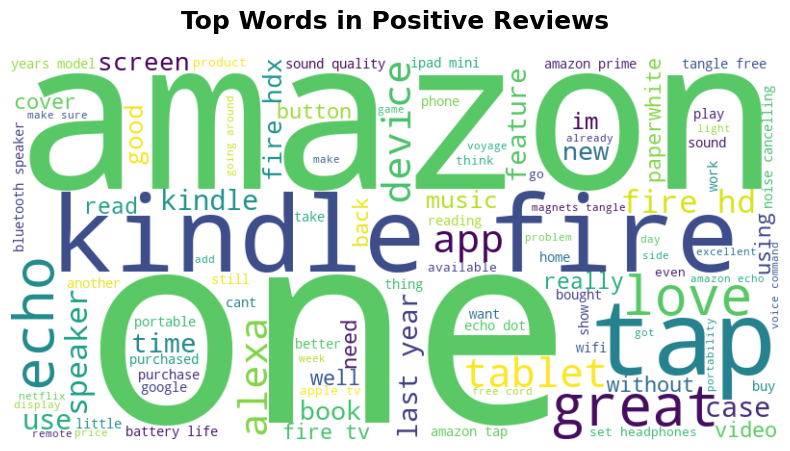

Generating WordCloud for Negative Reviews...


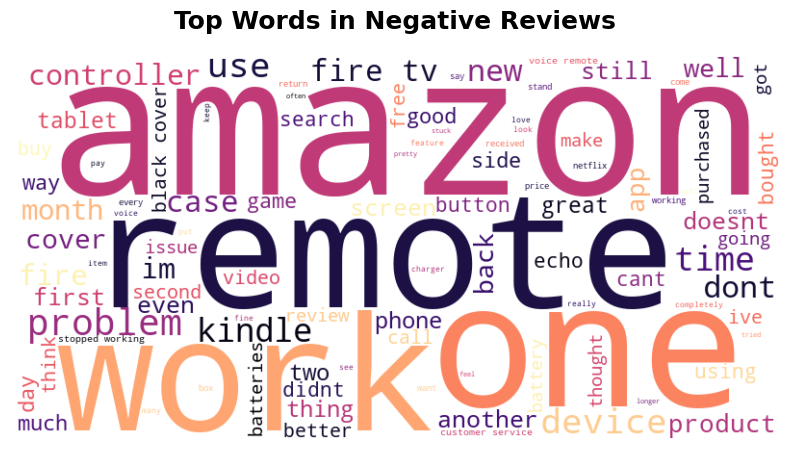

In [6]:
# 1. Import visualization libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 2. Combine all text for each sentiment into single large strings
# df is your main dataframe containing 'cleaned_text' and 'sentiment'
positive_reviews = " ".join(df[df['sentiment'] == 1]['cleaned_text'].astype(str))
negative_reviews = " ".join(df[df['sentiment'] == 0]['cleaned_text'].astype(str))

# 3. Create a helper function to generate and plot the WordCloud
def plot_wordcloud(text, title, colormap):
    # Initialize the WordCloud object with specific design parameters
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=colormap, 
                          max_words=100).generate(text)
    
    # Plot the image using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=18, color='black', pad=20, fontweight='bold')
    plt.axis('off') # Hide the x and y axes
    plt.show()

# 4. Generate the WordCloud for Positive Reviews (using a green/blue colormap)
print("Generating WordCloud for Positive Reviews...")
plot_wordcloud(positive_reviews, "Top Words in Positive Reviews", 'viridis')

# 5. Generate the WordCloud for Negative Reviews (using a red/orange colormap)
print("Generating WordCloud for Negative Reviews...")
plot_wordcloud(negative_reviews, "Top Words in Negative Reviews", 'magma')